Building likelihood maps for a set of representative images.

> TODO: use images from dataset and superimpose the bounding boxes on them

In [1]:
from retinotopy import *
welcome()

Running on GPU :  Tesla V100-SXM2-32GB #GPU= 1
Running on Jean Zay with Tesla V100-SXM2-32GB with DATAROOT='/lustre/fsn1/projects/rech/fsx/uvb28bo/data' and USER='uvb28bo' 


------------------------------------------------------------------------------------
On date 2025-03-06, Running learning on host r6i2n8 with device cuda, pytorch==2.6.0
------------------------------------------------------------------------------------
Welcome on Linux-5.14.0-427.50.1.el9_4.x86_64-x86_64-with-glibc2.34


In [2]:
# The dataset to import images from

data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use

args.do_saccade = True
args.do_resize = False
args.do_mask = False
args.do_polar = False

## doing the computations

In [3]:
pos_pred_zero = ((args.resolution[0]*args.resolution[1])//2)
retino_grid = get_grid(args).unsqueeze(0).to(device)
print(args)

annotations = None
#for model_data_set_type in data_set_types:
for model_data_set_type in ['bbox']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')

        
        for do_polar in [True, False]:
            sum_map = []
            do_polar = do_polar if model_data_set_type != 'raw' else False

            args.do_polar = do_polar
            print(f'{args.do_polar=}')

            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_Imagenet_mean_map_test.parquet'
            print(df_filename)
            
            if os.path.isfile(df_filename):
                continue
            else:
                df_map = None
                
                print(50*'.')
                
                model_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '.pt' if model_data_set_type != 'raw' else None

                #model_filename = f"cached_data/2024-03-04_{model_name}_do_polar={do_polar}_do_rottrain=False.pt"
                
                model = load_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
                
                if annotations is None:
                    annotations = get_annotation('csv')

                with torch.no_grad():
                    # image_datasets = datasets_transforms(args, verbose=False)['val']
                    image_datasets = image_datasets_transforms(args, shuffle=False, verbose=False)['val']
                    
                    for i_image, (images, label) in tqdm(enumerate(image_datasets)):

                        image_name = image_datasets.samples[i_image][0].split('/')[-1].split('.')[0]
                        
                        ground_true_indices, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Imagenet')
                        
                        if ground_true.min() == 0.0:
                            
                            since = time.time()
                            

                            
                            images = images.to(device, non_blocking=True)

                            heat_map = model(images)
                            heat_map = torch.nn.functional.softmax(heat_map, dim=1)
                            proba_label = heat_map[:, label].reshape(args.resolution)
                            arg_max_prior = torch.argmax(proba_label)
                            position_prior = (arg_max_prior.item()//min(args.resolution), arg_max_prior.item()%min(args.resolution))
                            sum_map.append(collect_centered_map(args, proba_label, position_prior))
                            #sum_map.append(proba_label)


                mean_map = torch.stack(sum_map).nanmean(dim=0)  
                mean_map = np.array(mean_map.cpu())
                #fig, ax = plt.subplots(1, 1, figsize=(10, 10))
                #sns.heatmap(mean_map, linewidth = 0 , annot = False, cmap=cmap, vmin=0, vmax=1, cbar = False, alpha=.5, ax=ax)
                mean_map = mean_map.reshape(args.resolution[0]*args.resolution[1])
                df_map_ = pd.DataFrame({'ImageId':[image_name], 'mean_map': [mean_map]})
                df_map = store_pandas(df_map, df_map_)
               
            df_map.to_parquet(df_filename)   

Params(datetag='2025-03-06', loader='data/Imagenet_urls_ILSVRC_2016.json', annotations_animal='data/Animal10k_annotations.json', annotations_train='data/LOC_train_solution.csv', annotations_val='data/LOC_val_solution.csv', folders=['val'], tasks=['animal', 'dog', 'cat', 'bird'], image_size=224, num_epochs=10, n_train_stop=0, seed=1998, batch_size=128, batch_size_val=128, lr=5e-05, momentum=0.02, beta2=0, rs_min=0.0, rs_max=-5.0, do_polar=False, do_raw=False, do_translate=False, do_resize=False, do_mask=False, do_scratch=False, do_rotation=False, resolution=(11, 11), size_ratio=0.1, do_saccade=True, do_zoom=False, method='valid', saccade_type='multi', normalize=True, verbose=False)
model_data_set_type='bbox'
..................................................
args.do_polar=True
cached_data/2025-03-06_bbox_resnet101_retino_Imagenet_mean_map_test.parquet
..................................................


loading .... cached_data/2025-03-06_bbox_resnet101_retino.pt


TypeError: image_datasets_transforms() got an unexpected keyword argument 'shuffle'

In [4]:
def get_mean_map(model_data_set_type, model_name):

    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, True) + f'_Imagenet_mean_map_test.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    ret_map = np.array(df['mean_map'][0].reshape(args.resolution[0], args.resolution[1]))
    
    
    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + f'_Imagenet_mean_map_test.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    cart_map = np.array(df['mean_map'][0].reshape(args.resolution[0], args.resolution[1]))
    
    
    df_filename = get_filename(data_cache, datetag, 'raw', model_name, False) + f'_Imagenet_mean_map.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    raw_map = np.array(df['mean_map'][0].reshape(args.resolution[0], args.resolution[1]))
    
    return raw_map, cart_map, ret_map

raw_map, cart_map, ret_map = get_mean_map('bbox', 'resnet101')

df_filename='cached_data/2025-03-06_bbox_resnet101_retino_Imagenet_mean_map_test.parquet'


FileNotFoundError: [Errno 2] No such file or directory: 'cached_data/2025-03-06_bbox_resnet101_retino_Imagenet_mean_map_test.parquet'

NameError: name 'raw_map' is not defined

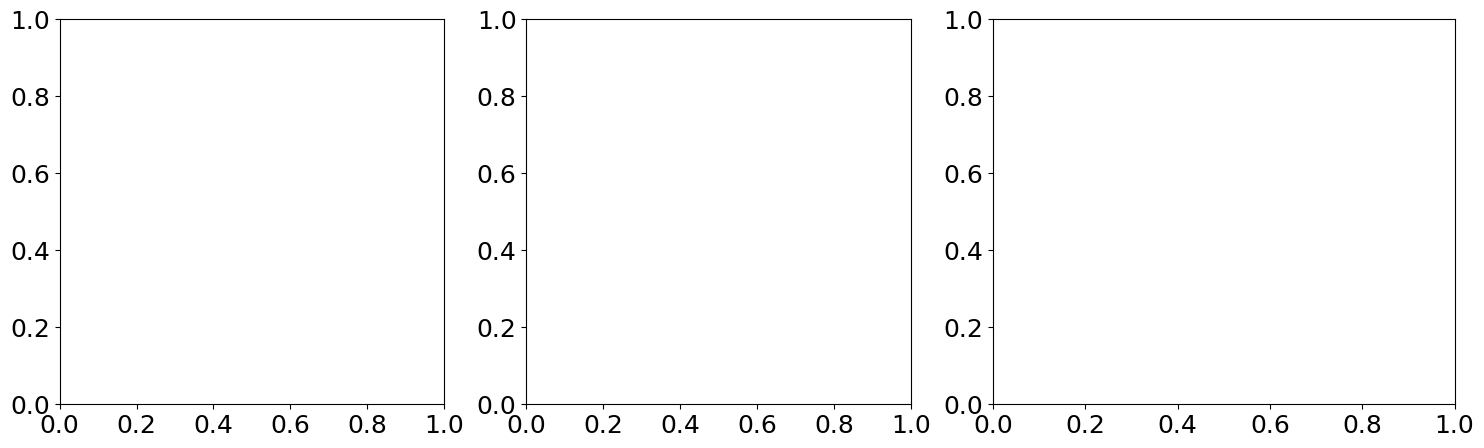

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), width_ratios=[1, 1, 1.2])
i = 0
all_titles = ['Raw', 'Cartesian', 'Retinotopic']
for i_model, result_map in enumerate([raw_map, cart_map, ret_map]):

    ax = axs[i_model]
    title_mod = all_titles[i_model]
    cbar = True if i_model == 2 else False
    X, Y = np.meshgrid(np.linspace(0, args.resolution[0], args.resolution[0]), np.linspace(0, args.resolution[1], args.resolution[1]))
    Z = result_map
    levels = np.linspace(Z.min(), Z.max(), max(args.resolution))
    
    sns.heatmap(result_map, linewidth = 1 , annot = False, cmap=cmap, vmin=0, vmax=1, fmt='.2g', cbar = cbar, ax=ax,annot_kws={"fontsize":9})
    CS = ax.contour(X, Y, Z, colors='black' )
    ax.clabel(CS, inline=True, fontsize=10)
    ax.set_title(f'Mean {title_mod} likelihood map', size = 20)
    ax.set_xticks([])
    ax.set_yticks([])
    #ax.imshow(result_map)

if False:
    to_save(fig, 'fig-mean_map_Imagenet_paper')

In [6]:
def get_odd_ratio(map1, map2, epsilon=1e-10):
    if map1.shape != map2.shape:
        print('Incompatible shape :(')
        return

    # Ensure probabilities are between 0 and 1 (not exactly 0 or 1)
    map1 = np.clip(map1, epsilon, 1 - epsilon)
    map2 = np.clip(map2, epsilon, 1 - epsilon)

    ones = np.ones(map1.shape)
    p1 = map1 / (ones - map1)  # odds for map1
    p2 = map2 / (ones - map2)  # odds for map2
    odd_ratio = p1 / p2

    return np.log(odd_ratio)


NameError: name 'cart_map' is not defined

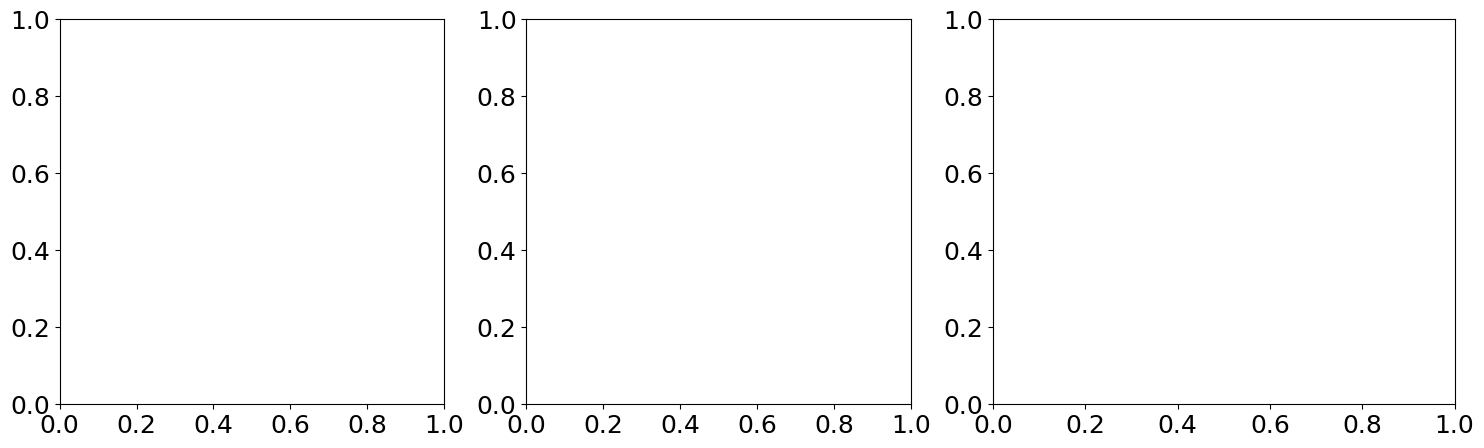

In [7]:

fig, axs = plt.subplots(1, 3, figsize=(18, 5), width_ratios=[1, 1, 1.2])

map = cart_map-raw_map
CS = axs[0].contour(X, Y, map, colors='black' )
axs[0].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = False, vmin=-.25, vmax=.25, ax=axs[0], annot_kws={"fontsize":9})
axs[0].set_title(' Cartesian map -  Raw map', size = 20)
axs[0].set_xticks([])
axs[0].set_yticks([])


map = ret_map-raw_map
CS = axs[1].contour(X, Y, map, colors='black' )
axs[1].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', ax=axs[1],cbar = False, vmin=-.25, vmax=.25, annot_kws={"fontsize":9})
axs[1].set_title(' Retinotopic map -  Raw map', size = 20)
axs[1].set_xticks([])
axs[1].set_yticks([])


cmap_bis = matplotlib.colors.LinearSegmentedColormap.from_list("", ["darkblue",  "lightsteelblue", "lavender", "white"])

map = ret_map-cart_map
CS = axs[2].contour(X, Y, map, colors='black' )
axs[2].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = True, vmin=-.25, vmax=0.25, ax=axs[2], annot_kws={"fontsize":9})
axs[2].set_title(' Retinotopic map -  Cartesian map', size = 20)
axs[2].set_xticks([])
axs[2].set_yticks([])

if False:
    to_save(fig, 'fig-mean_map_Imagenet_diff_paper')

NameError: name 'cart_map' is not defined

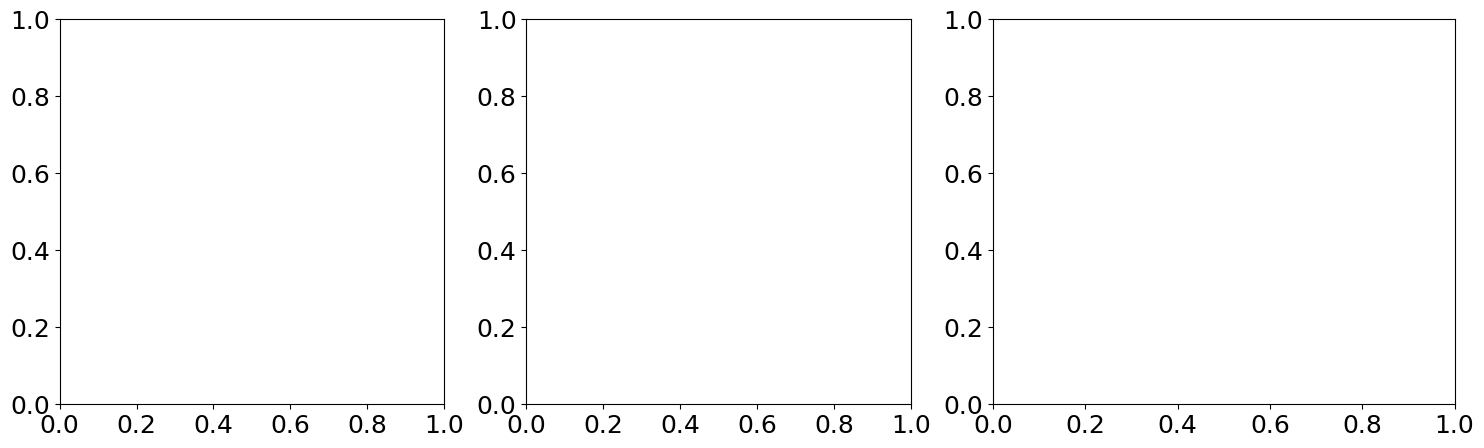

In [8]:

fig, axs = plt.subplots(1, 3, figsize=(18, 5), width_ratios=[1, 1, 1.2])


#map = cart_map-raw_map
map = get_odd_ratio(cart_map, raw_map)
CS = axs[0].contour(X, Y, map, colors='black' )
axs[0].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = False, vmin=-1, vmax=1, ax=axs[0], annot_kws={"fontsize":9})
axs[0].set_title('Log odd (Cartesian / Raw)', size = 20)
axs[0].set_xticks([])
axs[0].set_yticks([])


#map = ret_map-raw_map
map = get_odd_ratio(ret_map, raw_map)
CS = axs[1].contour(X, Y, map, colors='black' )
axs[1].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', ax=axs[1], cbar = False, vmin=-1, vmax=1, annot_kws={"fontsize":9})
axs[1].set_title('Log odd (Retinotopic / Raw)', size = 20)
axs[1].set_xticks([])
axs[1].set_yticks([])

#map = ret_map-cart_map
map = get_odd_ratio(ret_map, cart_map)
CS = axs[2].contour(X, Y, map, colors='black')
axs[2].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', vmin=1, vmax=-1, ax=axs[2], annot_kws={"fontsize":9})
axs[2].set_title('Log odd (Retinotopic / Cartesian)', size = 18)
axs[2].set_xticks([])
axs[2].set_yticks([])

if False:
    to_save(fig, 'fig-mean_map_Imagenet_odd_paper')

NameError: name 'raw_map' is not defined

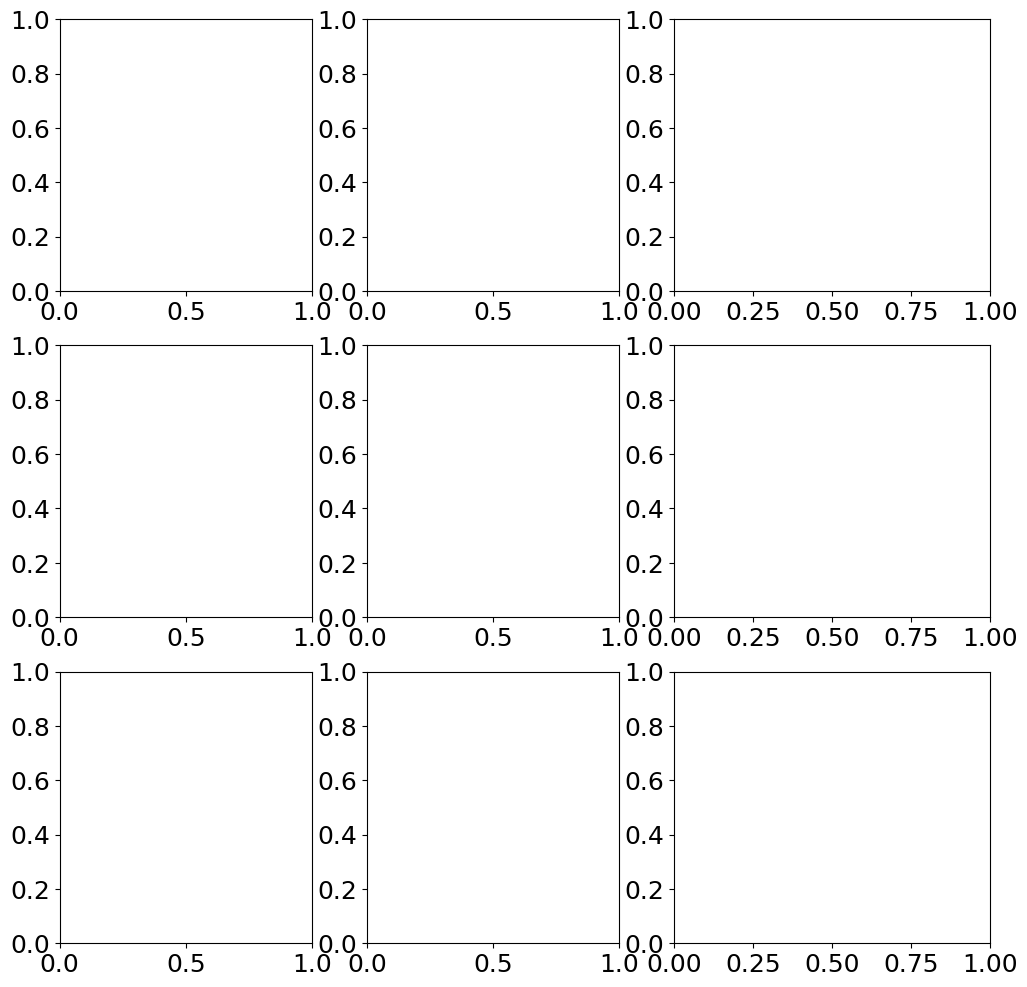

In [9]:

fig, axs = plt.subplots(3, 3, figsize=(12, 12), width_ratios=[1, 1, 1.25])
axs = axs.flat
i = 0
all_titles = ['Raw', 'Cartesian', 'Retinotopic']

for i_model, result_map in enumerate([raw_map, cart_map, ret_map]):

    ax = axs[i_model]
    title_mod = all_titles[i_model]
    cbar = True if i_model == 2 else False
    X, Y = np.meshgrid(np.linspace(0, args.resolution[0], args.resolution[0]), np.linspace(0, args.resolution[1], args.resolution[1]))
    Z = result_map
    levels = np.linspace(Z.min(), Z.max(), max(args.resolution))
    sns.heatmap(result_map, linewidth = 1 , annot = False, cmap=cmap, vmin=0, vmax=1, fmt='.2g', cbar = cbar, ax=ax, annot_kws={"fontsize":10})
    CS = ax.contour(X, Y, Z, colors='black' )
    ax.clabel(CS, inline=True, fontsize=10)
    ax.set_title(f'Mean {title_mod} likelihood map', size = fontsize)
    ax.set_xticks([])
    ax.set_yticks([])
    axs[0].set_ylabel(f"Mean likelihood map", size=fontsize)

i_model += 1 
ax = axs[i_model]
map = cart_map-raw_map
CS = ax.contour(X, Y, map, colors='black' )
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = False, vmin=-.25, vmax=.25, ax=ax, annot_kws={"fontsize":10})
ax.set_title(' Cartesian map -  Raw map', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel(f"Differences", size=fontsize)


i_model += 1
ax = axs[i_model] 
map = ret_map-raw_map
CS = ax.contour(X, Y, map, colors='black' )
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', ax=ax ,cbar = False, vmin=-.25, vmax=.25, annot_kws={"fontsize":10})
ax.set_title(' Retinotopic map -  Raw map', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])


i_model += 1
ax = axs[i_model]
map = ret_map-cart_map
CS = ax.contour(X, Y, map, colors='black' )
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = True, vmin=-.25, vmax=0.25, ax=ax, annot_kws={"fontsize":10})
ax.set_title(' Retinotopic map -  Cartesian map', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])

i_model += 1
ax = axs[i_model]
map = get_odd_ratio(cart_map, raw_map)
CS = ax.contour(X, Y, map, colors='black' )
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = False, vmin=-1, vmax=1, ax=ax, annot_kws={"fontsize":10})
ax.set_title('Log odd (Cartesian / Raw)', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel(f"Log-odd ratio", size=fontsize)


i_model += 1
ax = axs[i_model]
map = get_odd_ratio(ret_map, raw_map)
CS = ax.contour(X, Y, map, colors='black' )
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', ax=ax, cbar = False, vmin=-1, vmax=1, annot_kws={"fontsize":10})
ax.set_title('Log odd (Retinotopic / Raw)', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])

i_model += 1
ax = axs[i_model]
map = get_odd_ratio(ret_map, cart_map)
CS = ax.contour(X, Y, map, colors='black')
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', vmin=1, vmax=-1, ax=ax, annot_kws={"fontsize":10})
ax.set_title('Log odd (Retinotopic / Cartesian)', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

if False:
    to_save(fig, 'fig-complete_mean_maps_paper')